# 2 — Tous les votes ne se valent pas

**Ce que ce notebook établit :** agréger les scrutins sans distinguer leur
portée politique fausse les conclusions. L'accord LFI↔SOC passe de **79 %** sur
les amendements à **63 %** sur les votes d'ensemble ; RN↔DR fait le chemin
inverse, de **67 %** à **86 %**. Ce n'est pas un effet de taille d'échantillon,
et ça se vérifie.

**Le choix invisible de ce notebook : la population.** Le notebook `01` publie
des chiffres « tous scrutins confondus », sans que rien ne signale qu'il s'agit
d'un choix. On verra pourquoi ils sous-estiment les divisions à gauche et la
convergence à droite.

Suite du fil : `03` s'attaquera à la relation mesurée, `04` à la méthode.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from radar import analyze, viz
from radar.parse import load

viz.set_theme("clair")
pl.Config.set_tbl_rows(20)

polars.config.Config

## 1. L'hypothèse

Un vote sur un sous-amendement et un vote sur l'ensemble d'une loi n'engagent
pas de la même façon. Le premier est souvent **tactique** — on peut voter un
aménagement technique proposé par un adversaire sans rien approuver de son
texte, ou voter contre un amendement allié pour des raisons de calendrier. Le
second est un **positionnement public** sur le texte entier.

Si cette intuition est juste, alors la proximité entre deux groupes devrait
changer selon le type de scrutin considéré. Et comme les votes d'amendement
sont écrasants en nombre, une moyenne non pondérée mesurerait surtout de la
tactique parlementaire.

Première chose à vérifier : cet écrasement est-il réel ?

In [2]:
s = load("scrutins")
repartition = (
    s.group_by("portee", "categorie").len()
     .sort("len", descending=True)
     .with_columns((pl.col("len") / s.height).alias("part"))
)
repartition

portee,categorie,len,part
str,str,u32,f64
"""detail""","""amendement""",7216,0.855585
"""intermediaire""","""article""",872,0.103391
"""texte""","""ensemble""",222,0.026322
"""intermediaire""","""motion_procedure""",57,0.006758
"""intermediaire""","""autre""",25,0.002964
"""texte""","""motion_censure""",23,0.002727
"""intermediaire""","""declaration""",19,0.002253


86 % des scrutins publics portent sur un amendement. L'hypothèse mérite donc
d'être testée : si la portée change quelque chose, tout ce que le radar publie
« toutes portées confondues » décrit avant tout la vie des amendements.

## 2. La méthode de classement

Les titres de scrutins de l'AN suivent une syntaxe très régulière — « l'ensemble
de la proposition de loi… », « l'amendement n° 117 de M. X… », « la motion de
censure… ». On classe donc sur le titre, par une cascade d'expressions
régulières (`parse.CATEGORIES`), puis on regroupe en trois niveaux de portée.

Un classement lexical n'est acceptable que si on mesure son taux d'échec.

In [3]:
from radar.parse import CATEGORIES, PORTEES

for nom, motif in CATEGORIES:
    print(f"{nom:18s} {motif}")
print()
print("portées :", PORTEES)

motion_censure     ^la motion de censure
motion_procedure   ^la motion de (rejet|renvoi)|^la motion référendaire
ensemble           ^l.ensemble\b
amendement         ^(l.|les )(sous.)?amendements?\b|^le sous.amendement
article            ^(l.|les )articles?\b
declaration        ^la déclaration|^la demande

portées : {'motion_censure': 'texte', 'ensemble': 'texte', 'motion_procedure': 'intermediaire', 'article': 'intermediaire', 'declaration': 'intermediaire', 'amendement': 'detail', 'autre': 'intermediaire'}


In [4]:
# Taux de reconnaissance : la part de scrutins qui tombe dans « autre ».
non_classes = s.filter(pl.col("categorie") == "autre")
print(f"scrutins non reconnus : {non_classes.height} / {s.height} "
      f"({non_classes.height / s.height:.2%})")
print()
for t in non_classes["titre"].head(5).to_list():
    print(" •", (t or "")[:100])

scrutins non reconnus : 25 / 8434 (0.30%)

 • la première partie du projet de loi de finances pour 2025 (première lecture).
 • la proposition de résolution visant à mettre fin à la culpabilisation des victimes de violences phys
 • la proposition de résolution tendant à créer un Institut Océan de l'université des Nations unies en 
 • la proposition du Gouvernement de prolonger la séance en cours au-delà de vingt heures (proposition 
 • le sous-amendmeent n° 776 de Mme Mansouri à l'amendement n° 609 de Mme Firmin Le Bodo à l'article 4 


99,7 % des scrutins sont reconnus, et les 25 restants sont des cas isolés
(votes sur une résolution, sur une partie de loi de finances) qui ne relèvent
d'aucune des catégories courantes. Le classement tient.

Un point de méthode qui a son importance : **le drapeau officiel « scrutin
solennel » ne suffisait pas.** Il ne couvre que 72 scrutins, alors que 222 votes
portent sur l'ensemble d'un texte. S'y fier aurait fait perdre les deux tiers de
la population qui nous intéresse.

In [5]:
ensemble = s.filter(pl.col("categorie") == "ensemble")
print(f"votes sur l'ensemble d'un texte : {ensemble.height}")
print(f"  dont marqués « solennel »     : {ensemble.filter(pl.col('type_vote_code') == 'SPS').height}")

votes sur l'ensemble d'un texte : 222
  dont marqués « solennel »     : 65


## 3. Le test

On recalcule l'accord entre groupes sur les trois populations de scrutins, qui
sont **disjointes** : chaque scrutin appartient à une portée et une seule.

In [6]:
paires = [("LFI-NFP", "SOC"), ("LFI-NFP", "ECOS"), ("RN", "DR"),
          ("EPR", "DR"), ("EPR", "SOC"), ("LIOT", "EPR")]

comparaison = analyze.comparer_portees(paires)
comparaison.select("groupe_a", "groupe_b", "portee", "n_scrutins", "accord")

groupe_a,groupe_b,portee,n_scrutins,accord
str,str,str,i32,f64
"""EPR""","""DR""","""detail""",7216,0.710057
"""EPR""","""DR""","""intermediaire""",973,0.812071
"""EPR""","""DR""","""texte""",245,0.83237
"""EPR""","""SOC""","""detail""",7216,0.466304
"""EPR""","""SOC""","""intermediaire""",973,0.649373
"""EPR""","""SOC""","""texte""",245,0.537636
"""LFI-NFP""","""ECOS""","""detail""",7216,0.897674
"""LFI-NFP""","""ECOS""","""intermediaire""",973,0.765092
"""LFI-NFP""","""ECOS""","""texte""",245,0.82652


findfont: Failed to find font weight semibold, now using 700.


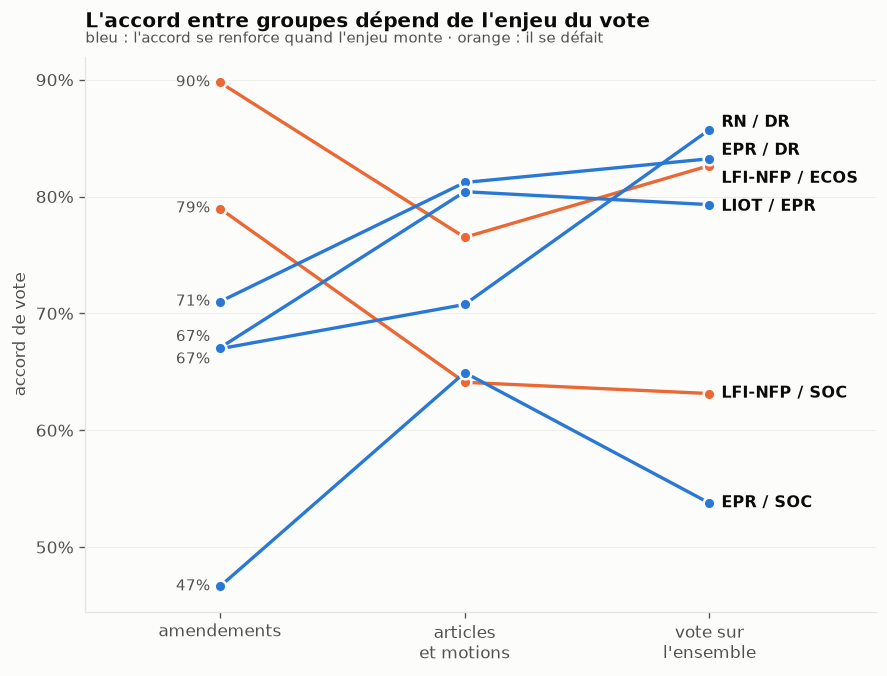

In [7]:
viz.pente_portees(comparaison, paires)
plt.show()

## 4. Le résultat

Les pentes ne vont pas dans le même sens, et c'est tout l'intérêt :

- **À gauche, l'accord se défait quand l'enjeu monte.** LFI↔SOC perd 16 points
  entre les amendements et les votes d'ensemble. Les deux groupes déposent et
  soutiennent les mêmes amendements, puis divergent au moment de voter le texte.
- **À droite, il se renforce.** RN↔DR gagne 19 points, EPR↔DR 12 points. La
  convergence ne se voit pas sur les amendements — où chacun défend ses propres
  rédactions — mais sur le vote final.

Autrement dit, les deux blocs fonctionnent à l'inverse l'un de l'autre, et une
moyenne unique masque exactement ce qui les distingue.

Second effet, moins visible mais important : la carte des députés devient bien
plus lisible dès qu'on retire les amendements.

In [8]:
(comparaison.select("portee", "n_scrutins", "inertie_axe1")
            .unique()
            .sort("inertie_axe1"))

portee,n_scrutins,inertie_axe1
str,i32,f64
"""intermediaire""",973,0.165381
"""detail""",7216,0.241363
"""texte""",245,0.384575


Le premier axe capte 24 % de la variance sur les amendements contre 39 % sur les
votes d'ensemble. Le clivage politique structure bien mieux les votes qui
engagent — ce qui est rassurant, et confirme qu'on mesure quelque chose de réel.

## 5. La contre-épreuve

L'objection évidente : il y a 7 216 votes d'amendement contre 245 votes
d'ensemble. Un écart entre deux échantillons aussi déséquilibrés pourrait n'être
que du bruit.

Le test : tirer au hasard, quarante fois, 245 votes d'amendement, et regarder si
la valeur observée sur les textes tombe dans l'étendue de ces tirages. Si oui,
on ne conclut rien.

In [9]:
robustesse = analyze.verifier_taille_echantillon(
    [("LFI-NFP", "SOC"), ("RN", "DR"), ("EPR", "DR")], n_tirages=40
)
robustesse

groupe_a,groupe_b,accord_sur_textes,amendements_moyenne,amendements_min,amendements_max,hors_intervalle
str,str,f64,f64,f64,f64,bool
"""LFI-NFP""","""SOC""",0.631411,0.799635,0.719339,0.866025,true
"""RN""","""DR""",0.857262,0.662548,0.569849,0.74317,true
"""EPR""","""DR""",0.83237,0.69191,0.612212,0.771536,true


Les trois paires tombent **hors** de l'étendue des tirages. L'écart n'est pas un
artefact d'échantillonnage : la portée du scrutin explique quelque chose que le
hasard n'explique pas.

## 6. Ce que ça change concrètement

Toute publication du radar doit désormais préciser sa population de scrutins.
En pratique, `build_cube` accepte un filtre `portee` :

```python
analyze.build_cube(portee="texte")     # les votes qui engagent
analyze.build_cube(portee="detail")    # la vie des amendements
```

et la comparaison est disponible en une commande :

```bash
uv run radar portees
```

**Limite honnête.** Trois niveaux de portée, c'est une simplification. Un vote
sur un article central d'une loi de finances pèse plus qu'un vote sur un article
de coordination, et rien ici ne les distingue. Rattacher chaque scrutin à son
dossier législatif permettrait de pondérer par l'importance du texte lui-même —
c'est la suite naturelle de ce travail.